In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# -------------------------------------------------------------
# Directories
# -------------------------------------------------------------
DATA_DIR  = "../outputs/datasets/"
MODEL_DIR = "../outputs/models/"
PRED_DIR  = "../outputs/models/predictions/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# -------------------------------------------------------------
# Targets and config
# -------------------------------------------------------------
TARGET_MAP = {
    "Throughput": "Perf_Avg_Throughput",
    "Latency":    "Perf_Avg_Latency",
    "Loss":       "Perf_Avg_Loss",
}

EXCLUDE = [
    "StartDateTime", "EndDateTime",
    "Perf_Filename", "ND_Filename",
    "RunDateTime"
]

WINDOW_SIZE = 1         # each row = 1-step sequence
BATCH_SIZE  = 32
EPOCHS      = 60
LR          = 1e-3


# ============================================================
# 1. Load dataset and extract X / y
# ============================================================

def load_split_data():
    df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
    df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    return df_train, df_valid, df_test


def extract_xy(df):
    """
    Robust extractor: independent of any global TARGETS variable.
    """
    # Drop meta columns if present
    df = df.drop(columns=[c for c in EXCLUDE if c in df.columns], errors="ignore")

    # Numeric-only
    df_num = df.select_dtypes(include=[np.number])

    target_cols = list(TARGET_MAP.values())
    feature_cols = [c for c in df_num.columns if c not in target_cols]

    X = df_num[feature_cols].fillna(0).values.astype(np.float32)

    y = {
        "Throughput": df_num[TARGET_MAP["Throughput"]].fillna(0).values.astype(np.float32),
        "Latency":    df_num[TARGET_MAP["Latency"]].fillna(0).values.astype(np.float32),
        "Loss":       df_num[TARGET_MAP["Loss"]].fillna(0).values.astype(np.float32),
    }

    return X, y, feature_cols


# ============================================================
# 2. Sequence builder (always returns N sequences if N>0)
# ============================================================

def make_sequence_dataset(X, y, window=1):
    """
    For this project we keep window=1:
    each row becomes a sequence of length 1.

    If you later want true windows, you can extend this,
    but this version guarantees that even tiny splits
    still produce sequences.
    """
    N = len(X)

    if N == 0:
        return np.empty((0, 1, X.shape[1])), np.empty((0,), dtype=np.float32)

    # Each row → 1-step sequence
    X_seq = X.reshape(N, 1, X.shape[1])
    y_seq = y.copy()

    return X_seq, y_seq


# ============================================================
# 3. BiLSTM model
# ============================================================

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        # bidirectional → 2 * hidden_dim
        self.fc = nn.Linear(2 * hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]          # (batch, 2*hidden)
        return self.fc(last)


# ============================================================
# 4. Train a single BiLSTM
# ============================================================

def train_single_bilstm(X_train, y_train, X_valid, y_valid,
                        model_name, input_dim):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = BiLSTMModel(input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    )
    valid_ds = TensorDataset(
        torch.tensor(X_valid, dtype=torch.float32),
        torch.tensor(y_valid, dtype=torch.float32).unsqueeze(1)
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE)

    best_loss = float("inf")
    best_state = None
    patience = 0
    patience_limit = 10

    for epoch in range(EPOCHS):
        # ----------------- Train -----------------
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= max(1, len(train_loader))

        # ----------------- Valid -----------------
        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                valid_loss += loss_fn(pred, yb).item()

        valid_loss /= max(1, len(valid_loader))

        print(f"[{model_name}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train={train_loss:.4f} | Valid={valid_loss:.4f}")

        # Early stopping
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_state = model.state_dict()
            patience = 0
        else:
            patience += 1
            if patience >= patience_limit:
                print(f"[{model_name}] Early stopping at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Save model
    model_path = os.path.join(MODEL_DIR, f"bilstm_model_{model_name.lower()}.pt")
    torch.save(model.state_dict(), model_path)
    print(f"[{model_name}] Saved model → {model_path}")

    return model


# ============================================================
# 5. Prediction helper
# ============================================================

def predict_bilstm(model, X):
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X, dtype=torch.float32).to(device))
    return preds.cpu().numpy().flatten()


# ============================================================
# 6. Full training pipeline (train + save predictions)
# ============================================================

def train_bilstm_pipeline():

    df_train, df_valid, df_test = load_split_data()

    X_train, y_train_dict, feature_cols = extract_xy(df_train)
    X_valid, y_valid_dict, _           = extract_xy(df_valid)
    X_test,  y_test_dict, _            = extract_xy(df_test)

    input_dim = X_train.shape[1]
    print(f"BiLSTM input_dim = {input_dim}, WINDOW_SIZE = {WINDOW_SIZE}")

    for target_name in ["Throughput", "Latency", "Loss"]:
        print(f"\n==== BiLSTM training for {target_name} ====")

        y_train = y_train_dict[target_name]
        y_valid = y_valid_dict[target_name]
        y_test  = y_test_dict[target_name]

        Xtr, ytr = make_sequence_dataset(X_train, y_train, WINDOW_SIZE)
        Xva, yva = make_sequence_dataset(X_valid, y_valid, WINDOW_SIZE)
        Xte, yte = make_sequence_dataset(X_test,  y_test,  WINDOW_SIZE)

        # Safety check: skip if no training data
        if len(Xtr) == 0:
            print(f"[{target_name}] Skipping – no training samples.")
            continue

        model = train_single_bilstm(Xtr, ytr, Xva, yva, target_name, input_dim)

        # Predictions on valid + test
        pred_valid = predict_bilstm(model, Xva)
        pred_test  = predict_bilstm(model, Xte)

        # Save predicted vs actual
        pd.DataFrame({"y_true": yva, "y_pred": pred_valid}).to_csv(
            os.path.join(PRED_DIR, f"bilstm_{target_name}_valid_predictions.csv"),
            index=False
        )
        pd.DataFrame({"y_true": yte, "y_pred": pred_test}).to_csv(
            os.path.join(PRED_DIR, f"bilstm_{target_name}_test_predictions.csv"),
            index=False
        )

        print(f"[{target_name}] Saved predictions (valid & test).")


# ============================================================
# 7. Script entry
# ============================================================

if __name__ == "__main__":
    train_bilstm_pipeline()


BiLSTM input_dim = 103, WINDOW_SIZE = 1

==== BiLSTM training for Throughput ====
[Throughput] Epoch 1/60 | Train=0.0989 | Valid=0.0420
[Throughput] Epoch 2/60 | Train=0.0728 | Valid=0.0260
[Throughput] Epoch 3/60 | Train=0.0489 | Valid=0.0137
[Throughput] Epoch 4/60 | Train=0.0299 | Valid=0.0053
[Throughput] Epoch 5/60 | Train=0.0162 | Valid=0.0008
[Throughput] Epoch 6/60 | Train=0.0066 | Valid=0.0002
[Throughput] Epoch 7/60 | Train=0.0014 | Valid=0.0029
[Throughput] Epoch 8/60 | Train=0.0004 | Valid=0.0080
[Throughput] Epoch 9/60 | Train=0.0025 | Valid=0.0142
[Throughput] Epoch 10/60 | Train=0.0060 | Valid=0.0229
[Throughput] Epoch 11/60 | Train=0.0099 | Valid=0.0231
[Throughput] Epoch 12/60 | Train=0.0113 | Valid=0.0230
[Throughput] Epoch 13/60 | Train=0.0117 | Valid=0.0218
[Throughput] Epoch 14/60 | Train=0.0107 | Valid=0.0193
[Throughput] Epoch 15/60 | Train=0.0087 | Valid=0.0159
[Throughput] Epoch 16/60 | Train=0.0064 | Valid=0.0123
[Throughput] Early stopping at epoch 16
[Throug

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/"
os.makedirs(PLOT_DIR, exist_ok=True)

TARGETS = ["Throughput", "Latency", "Loss"]

plt.style.use("seaborn-v0_8-whitegrid")


# ============================================================
# Load BiLSTM predictions
# ============================================================

def load_bilstm_predictions(metric, split):
    """
    Loads prediction CSV files generated by bilstm_training.py
    """
    path = os.path.join(PRED_DIR, f"bilstm_{metric}_{split}_predictions.csv")

    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing prediction file: {path}")

    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


# ============================================================
# Predicted vs Actual scatter
# ============================================================

def plot_pred_vs_actual(y_true, y_pred, title, outfile, showImage=False):

    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, edgecolor=None)

    # Identity line
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=2, label="Ideal")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    print(f"Saved → {outfile}")

    if showImage:
        plt.show()
    else:
        plt.close()


# ============================================================
# Time-series plot
# ============================================================

def plot_time_series(y_true, y_pred, title, outfile, showImage=False):

    plt.figure(figsize=(12, 5))

    plt.plot(y_true.values, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linestyle="--", linewidth=2)

    plt.xlabel("Sample Index")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    print(f"Saved → {outfile}")

    if showImage:
        plt.show()
    else:
        plt.close()


# ============================================================
# Generate all BiLSTM plots
# ============================================================

def generate_bilstm_plots(showImage=False):

    for metric in TARGETS:
        print(f"\n=== Generating BiLSTM plots for {metric} ===")

        # ---------------------------------------------------
        # VALIDATION SET
        # ---------------------------------------------------
        try:
            yv, pv = load_bilstm_predictions(metric, "valid")

            plot_pred_vs_actual(
                yv, pv,
                title=f"BiLSTM – Predicted vs Actual ({metric}, Validation)",
                outfile=os.path.join(PLOT_DIR, f"bilstm_{metric}_pred_valid.png"),
                showImage=showImage
            )

            plot_time_series(
                yv, pv,
                title=f"BiLSTM – Time Series ({metric}, Validation)",
                outfile=os.path.join(PLOT_DIR, f"bilstm_{metric}_ts_valid.png"),
                showImage=showImage
            )
        except FileNotFoundError:
            print(f"[WARNING] No validation predictions for {metric}")

        # ---------------------------------------------------
        # TEST SET
        # ---------------------------------------------------
        try:
            yt, pt = load_bilstm_predictions(metric, "test")

            plot_pred_vs_actual(
                yt, pt,
                title=f"BiLSTM – Predicted vs Actual ({metric}, Test)",
                outfile=os.path.join(PLOT_DIR, f"bilstm_{metric}_pred_test.png"),
                showImage=showImage
            )

            plot_time_series(
                yt, pt,
                title=f"BiLSTM – Time Series ({metric}, Test)",
                outfile=os.path.join(PLOT_DIR, f"bilstm_{metric}_ts_test.png"),
                showImage=showImage
            )
        except FileNotFoundError:
            print(f"[WARNING] No test predictions for {metric}")

    print("\nBiLSTM plots generated successfully!")



=== Generating BiLSTM plots for Throughput ===
Saved → ../outputs/models/plots/bilstm_Throughput_pred_valid.png


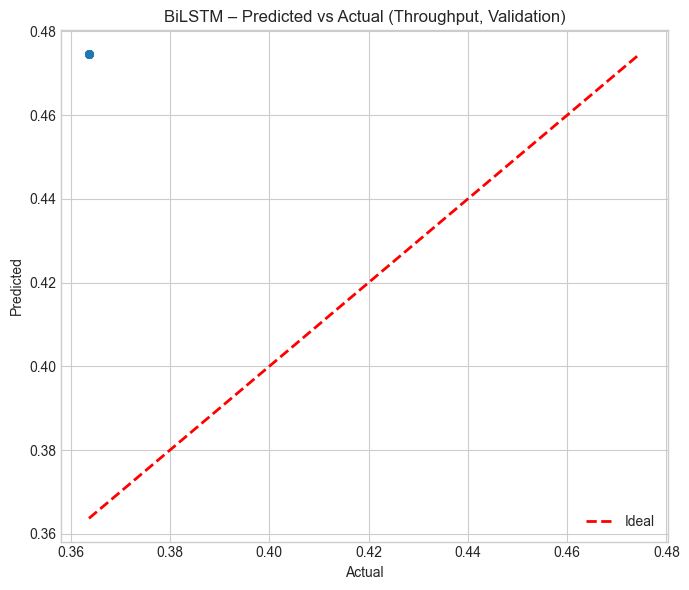

Saved → ../outputs/models/plots/bilstm_Throughput_ts_valid.png


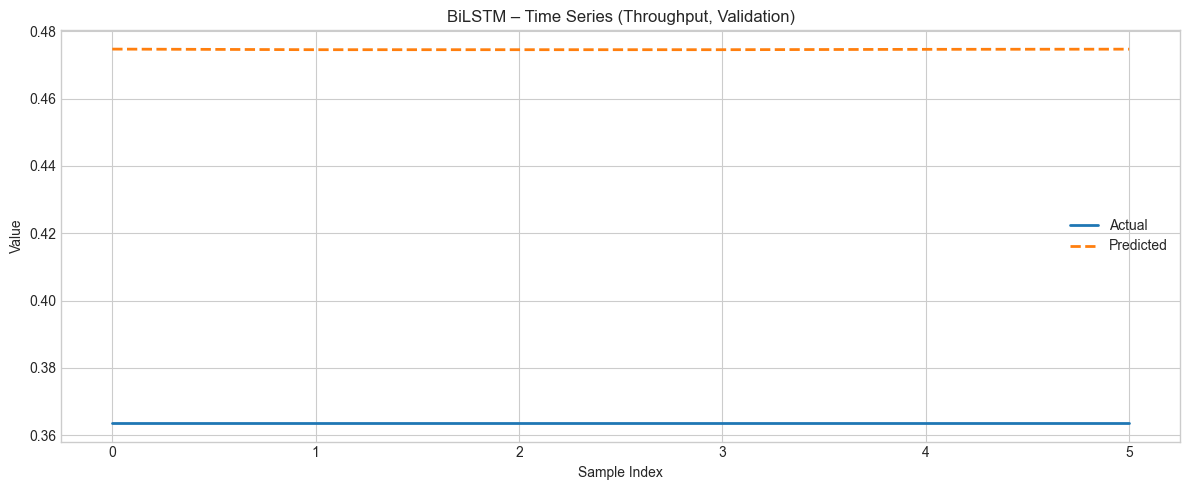

Saved → ../outputs/models/plots/bilstm_Throughput_pred_test.png


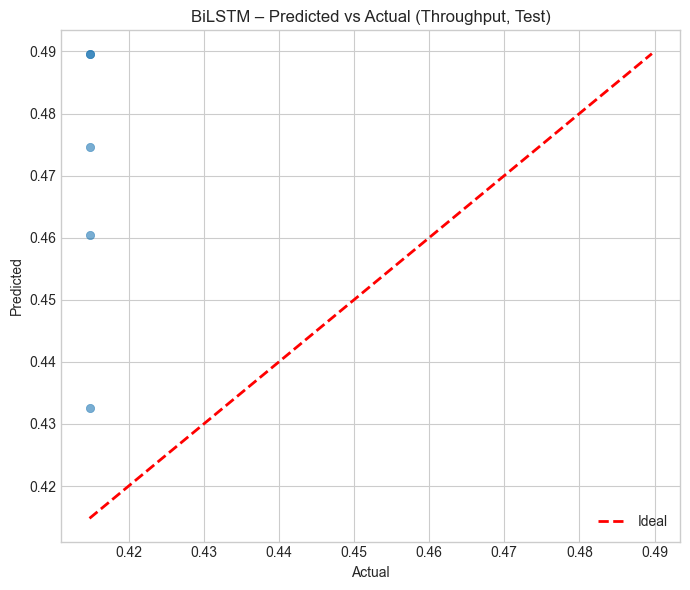

Saved → ../outputs/models/plots/bilstm_Throughput_ts_test.png


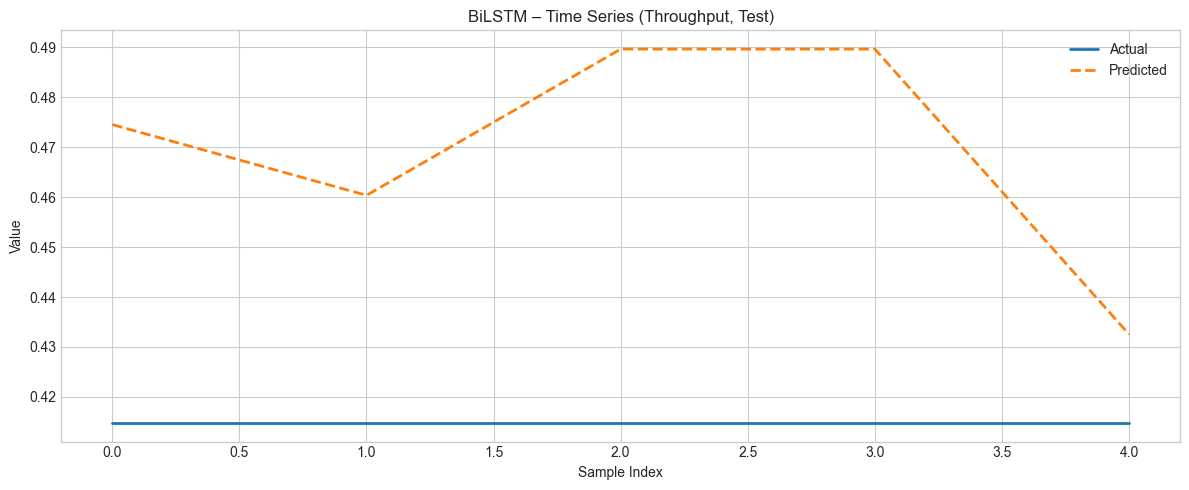


=== Generating BiLSTM plots for Latency ===
Saved → ../outputs/models/plots/bilstm_Latency_pred_valid.png


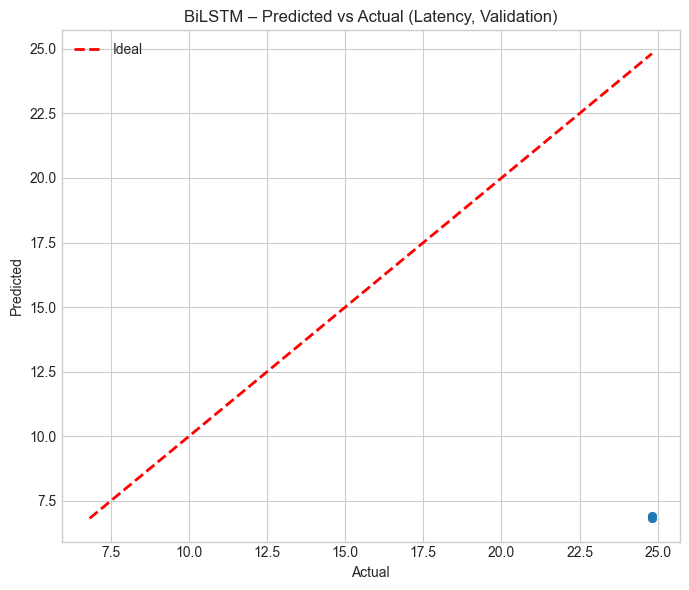

Saved → ../outputs/models/plots/bilstm_Latency_ts_valid.png


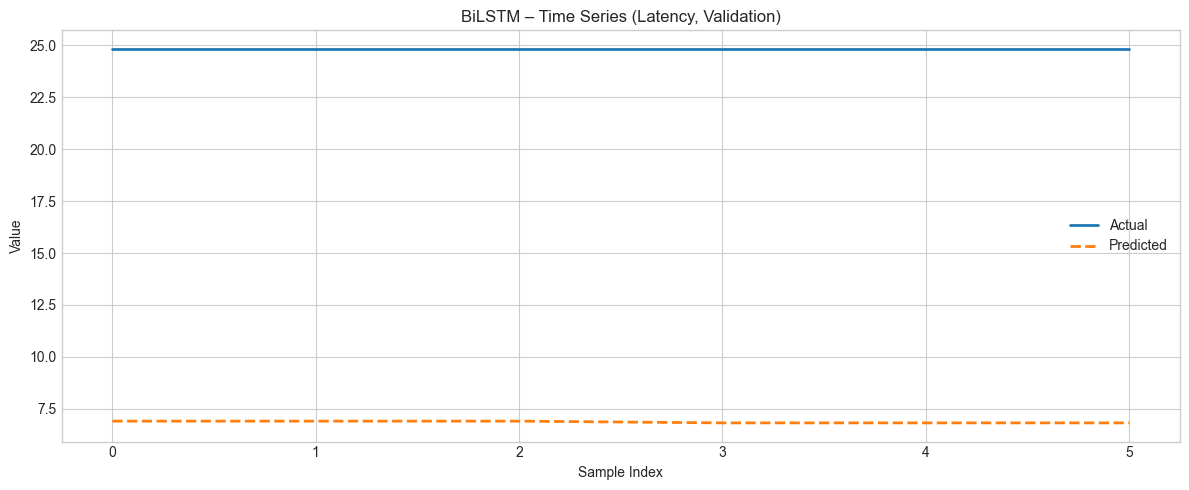

Saved → ../outputs/models/plots/bilstm_Latency_pred_test.png


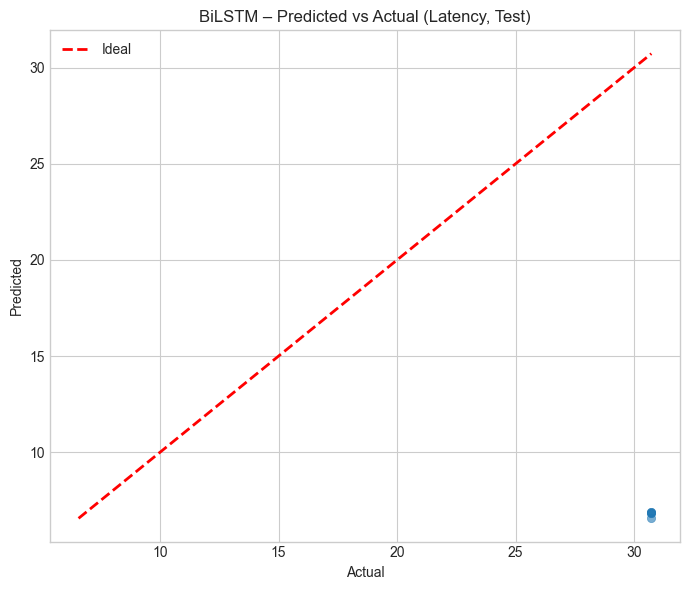

Saved → ../outputs/models/plots/bilstm_Latency_ts_test.png


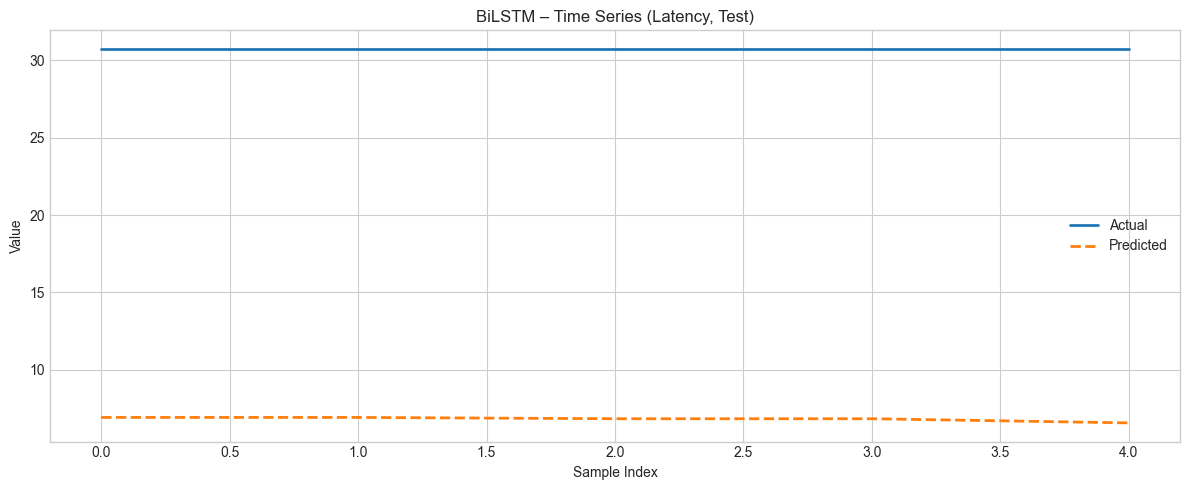


=== Generating BiLSTM plots for Loss ===
Saved → ../outputs/models/plots/bilstm_Loss_pred_valid.png


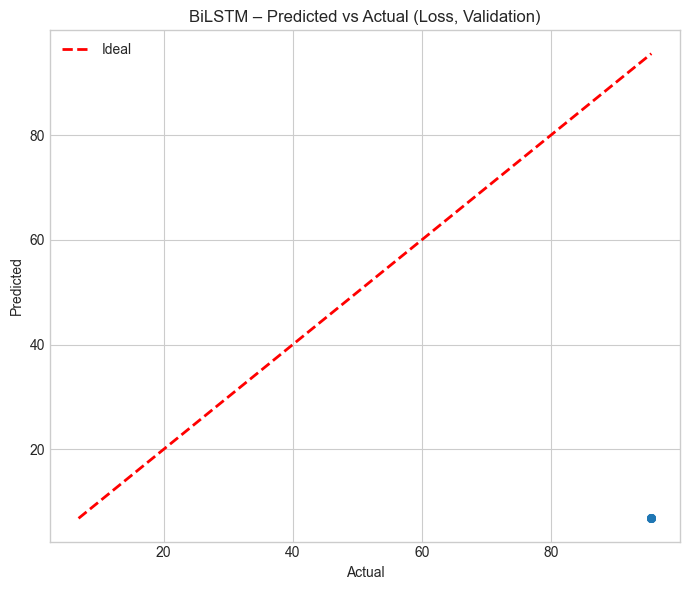

Saved → ../outputs/models/plots/bilstm_Loss_ts_valid.png


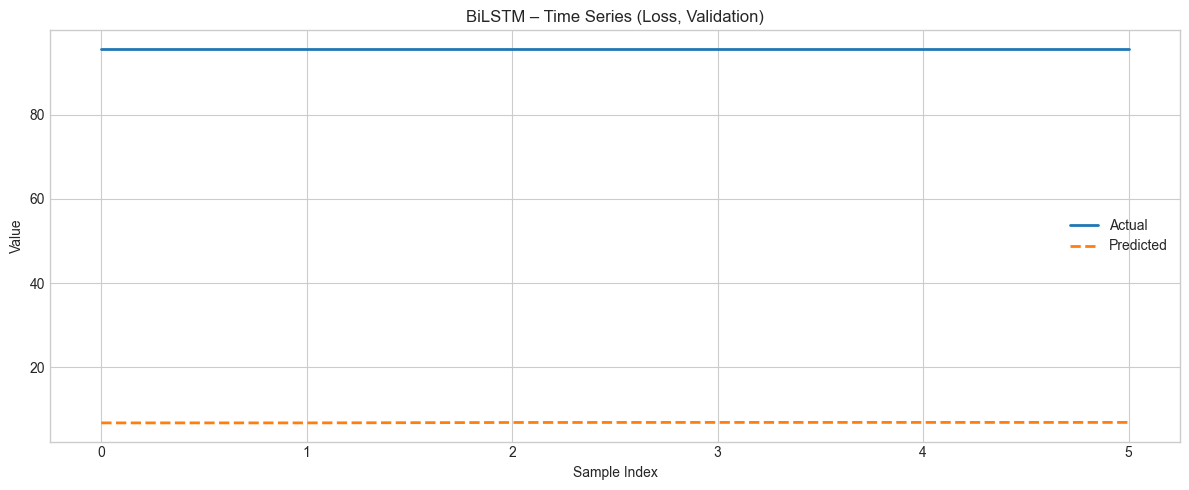

Saved → ../outputs/models/plots/bilstm_Loss_pred_test.png


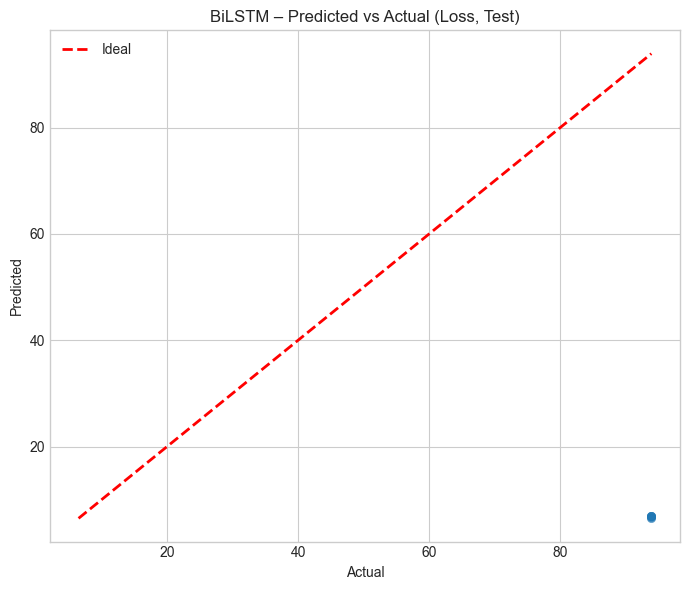

Saved → ../outputs/models/plots/bilstm_Loss_ts_test.png


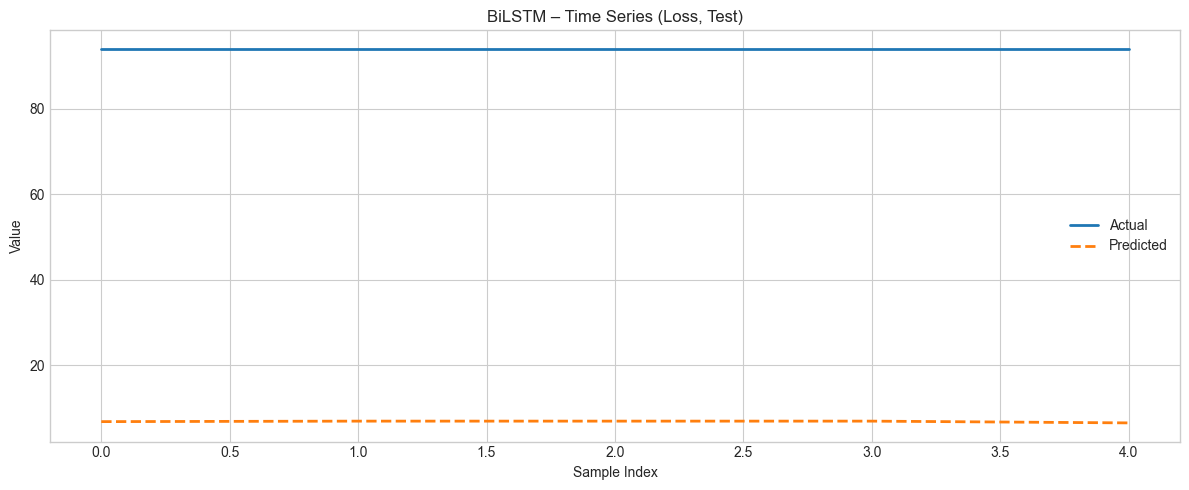


BiLSTM plots generated successfully!


In [4]:
# from bilstm_plots import generate_bilstm_plots
generate_bilstm_plots(showImage=True)


In [5]:
import os
import time
import torch
import torch.nn as nn
import numpy as np


# ============================================================
# 1. BiLSTM Model (must match your training architecture)
# ============================================================

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        # For BiLSTM → output size = 2*hidden_dim
        self.fc = nn.Linear(2 * hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]   # final timestep
        return self.fc(last)


# ============================================================
# 2. Load BiLSTM model weights
# ============================================================

def load_bilstm_model(model_path, input_dim):
    model = BiLSTMModel(input_dim)
    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model


# ============================================================
# 3. Count Parameters + Model Size
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def model_size_bytes(model):
    return count_parameters(model) * 4   # FP32


# ============================================================
# 4. FLOPs Calculation for BiLSTM
# ============================================================

def compute_bilstm_flops(model, sequence_len=1):
    """
    FLOPs for BiLSTM:

    For each LSTM direction:
      FLOPs_cell = 4 * H * (H + I + 1)

    For bidirectional:
      FLOPs_bidir = 2 * FLOPs_cell

    For L layers:
      FLOPs_lstm_total = L * sequence_len * FLOPs_bidir

    FC Layer:
      FLOPs_fc = 2 * (2*H) * 1
    """
    I = model.input_dim
    H = model.hidden_dim
    L = model.num_layers

    # Single-LSTM direction FLOPs
    flops_cell = 4 * H * (H + I + 1)

    # BiLSTM doubles this
    flops_bidir = 2 * flops_cell

    # Total LSTM FLOPs
    flops_lstm = L * sequence_len * flops_bidir

    # Final FC layer FLOPs
    flops_fc = 2 * (2 * H)

    return flops_lstm + flops_fc


# ============================================================
# 5. Latency Measurement
# ============================================================

def measure_latency(model, example_input, runs=200, warmup=20):

    device = "cpu"
    model.to(device)
    example_input = example_input.to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(example_input)

    # Timed inference runs
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(runs):
            _ = model(example_input)
    t1 = time.perf_counter()

    return (t1 - t0) / runs


# ============================================================
# 6. Simple Energy Estimate
# ============================================================

def estimate_energy(latency_s, power_W=2.0):
    """
    Approximate energy = P * t
    """
    return latency_s * power_W


# ============================================================
# 7. Peak Activation Memory
# ============================================================

def estimate_peak_activation_memory(model, example_input):
    with torch.no_grad():
        out = model(example_input)
    return out.numel() * 4   # FP32 byte size


# ============================================================
# 8. Full BiLSTM Edge Evaluation Pipeline
# ============================================================

def evaluate_bilstm_edge(model_path, input_dim, sequence_len=1, assumed_power_W=2.0):

    # Load model
    model = load_bilstm_model(model_path, input_dim)

    # Dummy input for FLOPs, latency, activations
    example_input = torch.randn(1, sequence_len, input_dim)

    # ---- Compute Metrics ----
    params = count_parameters(model)
    size_b = model_size_bytes(model)
    size_mb = size_b / (1024 * 1024)

    flops = compute_bilstm_flops(model, sequence_len)
    latency_s = measure_latency(model, example_input)
    latency_ms = latency_s * 1000

    energy = estimate_energy(latency_s, assumed_power_W)
    peak_mem = estimate_peak_activation_memory(model, example_input)

    # ---- Return Results ----
    return {
        "Model Path": model_path,
        "Parameters": params,
        "Model Size (Bytes)": size_b,
        "Model Size (MB)": size_mb,
        "FLOPs": flops,
        "Latency (s)": latency_s,
        "Latency (ms)": latency_ms,
        "Energy Estimated (J)": energy,
        "Peak Activation Memory (Bytes)": peak_mem
    }


In [6]:
# from bilstm_edge_evaluation import evaluate_bilstm_edge

input_dim = 103            # number of features
model_path = "../outputs/models/bilstm_model_throughput.pt"

metrics = evaluate_bilstm_edge(model_path, input_dim, sequence_len=1)

for k, v in metrics.items():
    print(f"{k}: {v}")


Model Path: ../outputs/models/bilstm_model_throughput.pt
Parameters: 185985
Model Size (Bytes): 743940
Model Size (MB): 0.7094764709472656
FLOPs: 172288
Latency (s): 0.000840166499838233
Latency (ms): 0.840166499838233
Energy Estimated (J): 0.001680332999676466
Peak Activation Memory (Bytes): 4


In [7]:
input_dim = 103            # number of features
model_path = "../outputs/models/bilstm_model_latency.pt"

metrics = evaluate_bilstm_edge(model_path, input_dim, sequence_len=1)

for k, v in metrics.items():
    print(f"{k}: {v}")

Model Path: ../outputs/models/bilstm_model_latency.pt
Parameters: 185985
Model Size (Bytes): 743940
Model Size (MB): 0.7094764709472656
FLOPs: 172288
Latency (s): 0.0009655484999530017
Latency (ms): 0.9655484999530017
Energy Estimated (J): 0.0019310969999060035
Peak Activation Memory (Bytes): 4


In [8]:
input_dim = 103            # number of features
model_path = "../outputs/models/bilstm_model_loss.pt"

metrics = evaluate_bilstm_edge(model_path, input_dim, sequence_len=1)

for k, v in metrics.items():
    print(f"{k}: {v}")

Model Path: ../outputs/models/bilstm_model_loss.pt
Parameters: 185985
Model Size (Bytes): 743940
Model Size (MB): 0.7094764709472656
FLOPs: 172288
Latency (s): 0.0013013815000886097
Latency (ms): 1.3013815000886098
Energy Estimated (J): 0.0026027630001772195
Peak Activation Memory (Bytes): 4
